In [136]:
import json
import os

import pandas as pd

# Plot the accuracy

dir = '../data/results/experiments/operator_experiment_24'

data_df = pd.read_csv(os.path.join(dir, 'results.csv')).drop(columns=['Unnamed: 0'])

data_df['operator'] = data_df['operator'].astype(int)

data_df['beamforming'] = data_df['operator'] != 1

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

diff_df = pd.DataFrame()

diff_df['error increase (m)'] = data_df['error'] - data_df['error_control']
diff_df['complexity reduction (%)'] = (data_df['complexity_control'] - data_df['complexity']) / data_df[
    'complexity_control'] * 100
diff_df['operator'] = data_df['operator']
diff_df['beamforming'] = data_df['beamforming']

control = data_df[['operator', 'n_clusters', 'beamforming', 'error_control', 'complexity_control']]
res = data_df[['operator', 'n_clusters', 'beamforming', 'error', 'complexity']]

control['pca'] = 'Without PCA'
res['pca'] = 'With PCA'

control.rename(columns={'error_control': 'error', 'complexity_control': 'complexity'}, inplace=True)

result_df = pd.concat([control, res], ignore_index=True)

result_df['complexity'] = result_df['complexity'] / 1000

diff_df.groupby(['beamforming']).mean()


/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_37490/748765449.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  control['pca'] = 'Without PCA'
/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_37490/748765449.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res['pca'] = 'With PCA'
/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_37490/748765449.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the docu

,error increase (m),complexity reduction (%),operator
beamforming,,,
False,1.302258,50.00000,1.000000
True,0.536487,43.35884,49.333333


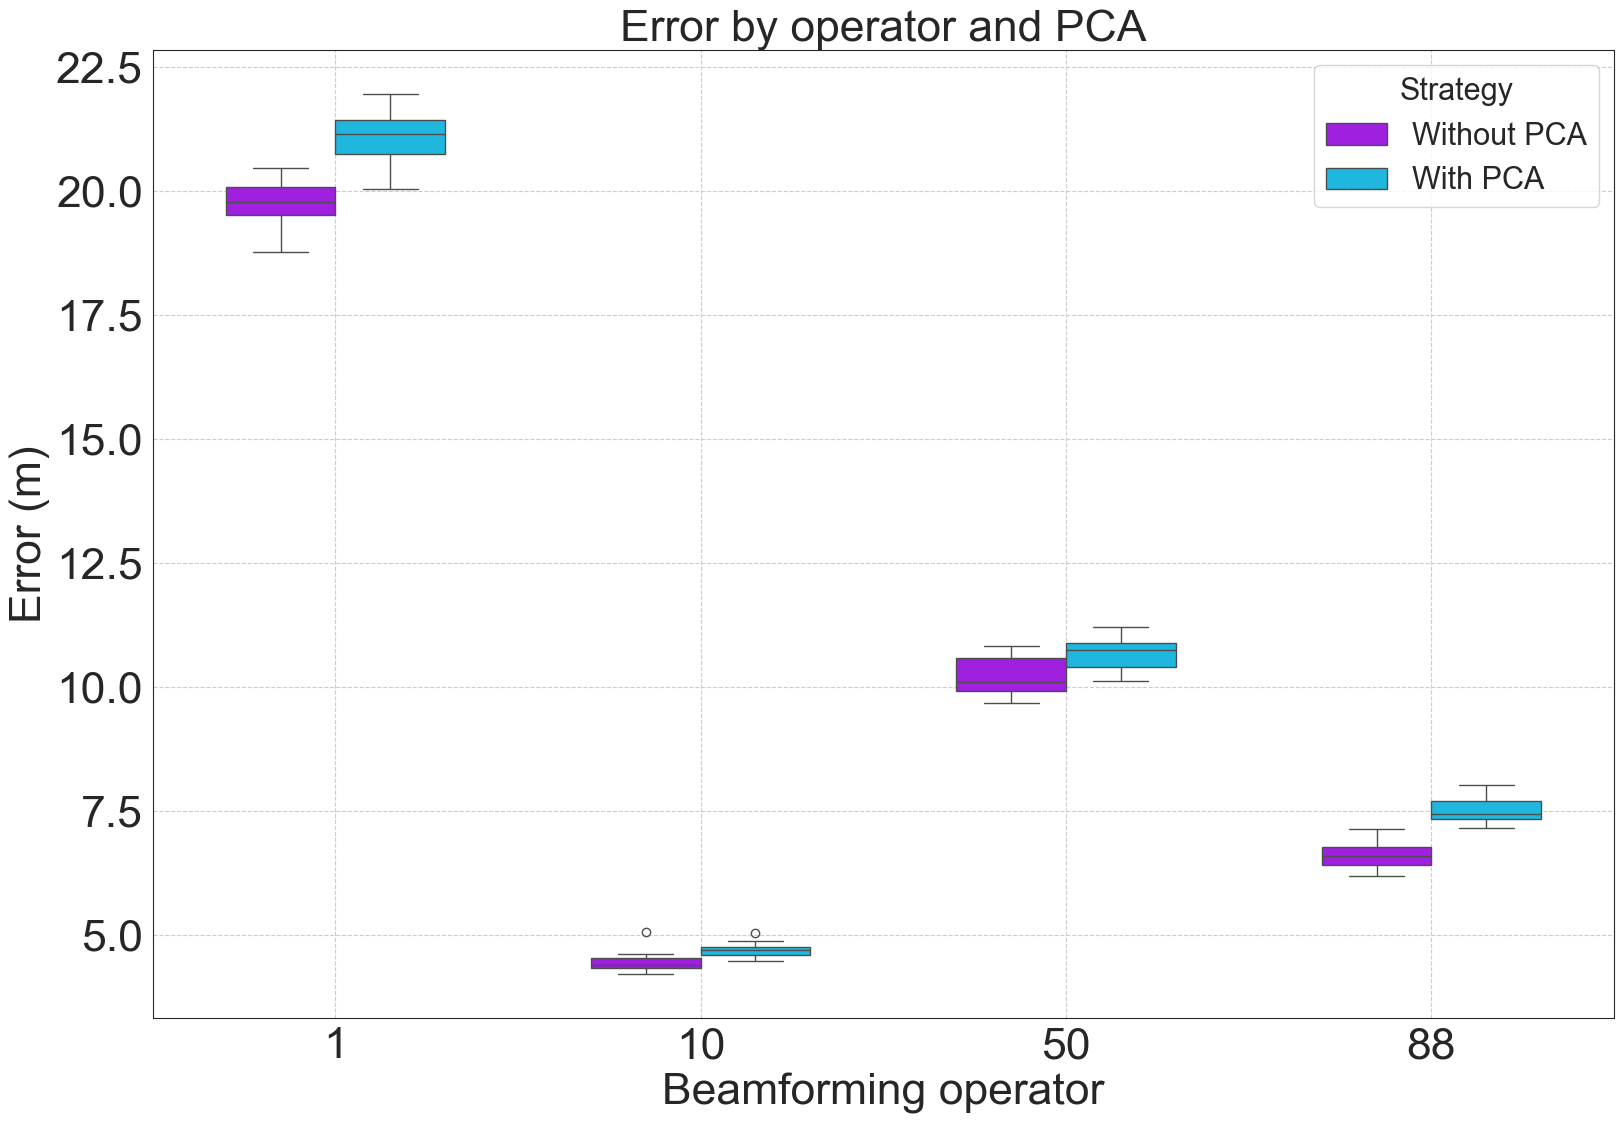

In [139]:

import seaborn as sns

palette = {'Without PCA': '#AA00FF', 'With PCA': '#00CAFF'}


def plot_pca_experiment(data_df: pd.DataFrame):
    color_map = get_config('color_map.json', 'operatorId')

    plt.rcParams.update({"font.size": 32})
    # Set the style to white background
    plt.figure(figsize=(17, 12))
    sns.set_style("white")

    sns.boxplot(x='operator', y='error', hue='pca', palette=palette, data=data_df, width=0.6)

    # Add labels and title
    plt.xlabel('Beamforming operator')
    plt.ylabel('Error (m)')
    plt.title('Error by operator and PCA')

    # Improve the legend
    plt.legend(title='Strategy', fontsize='22', loc='upper right', title_fontsize=22)

    # Remove grid or make it very subtle
    plt.grid(linestyle='--')

    from matplotlib.ticker import FormatStrFormatter

    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    # Show the plot
    plt.tight_layout()
    plt.show()


plot_pca_experiment(result_df)

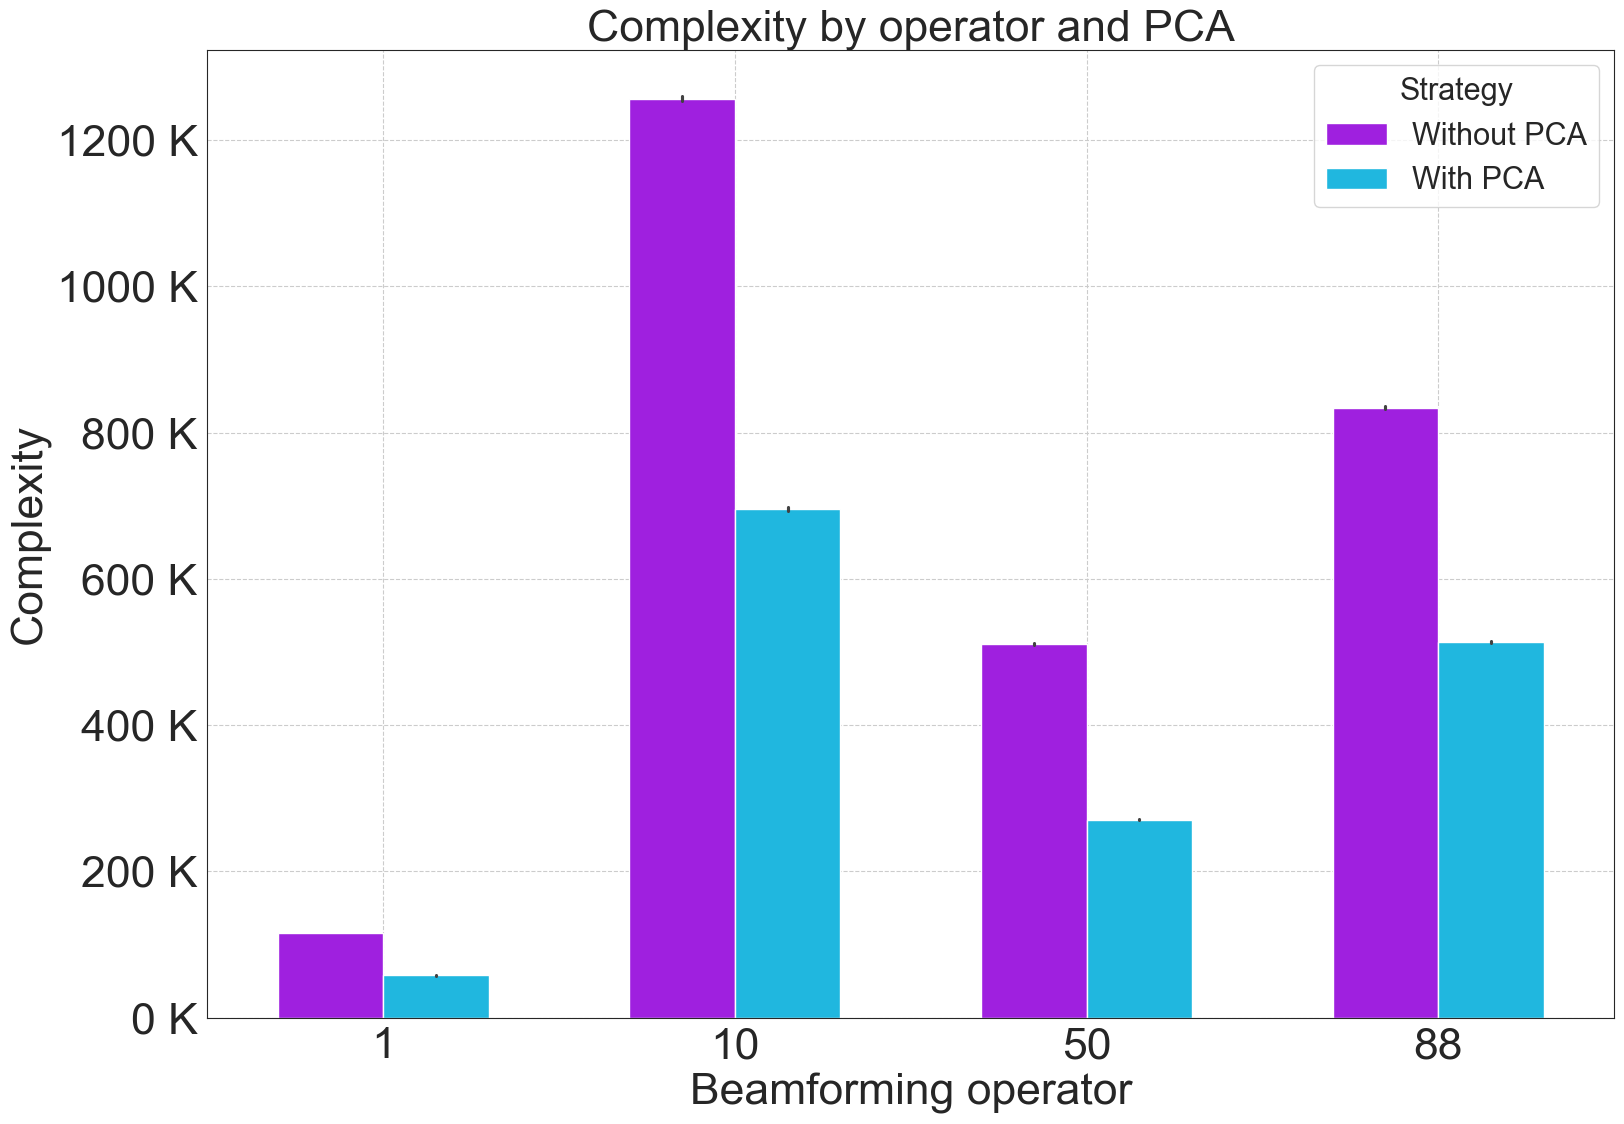

In [140]:
def plot_pca_experiment_complexity(data_df: pd.DataFrame):
    color_map = get_config('color_map.json', 'operatorId')

    plt.rcParams.update({"font.size": 32})
    # Set the style to white background
    plt.figure(figsize=(17, 12))
    sns.set_style("white")

    sns.barplot(x='operator', y='complexity', hue='pca', palette=palette, data=data_df, width=0.6)

    # Add labels and title
    plt.xlabel('Beamforming operator')
    plt.ylabel('Complexity')
    plt.title('Complexity by operator and PCA')

    # Improve the legend
    plt.legend(title='Strategy', fontsize='22', loc='upper right', title_fontsize=22)

    # Remove grid or make it very subtle
    plt.grid(linestyle='--')

    from matplotlib.ticker import FormatStrFormatter

    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.0f K'))

    # Show the plot
    plt.tight_layout()
    plt.show()


plot_pca_experiment_complexity(result_df)

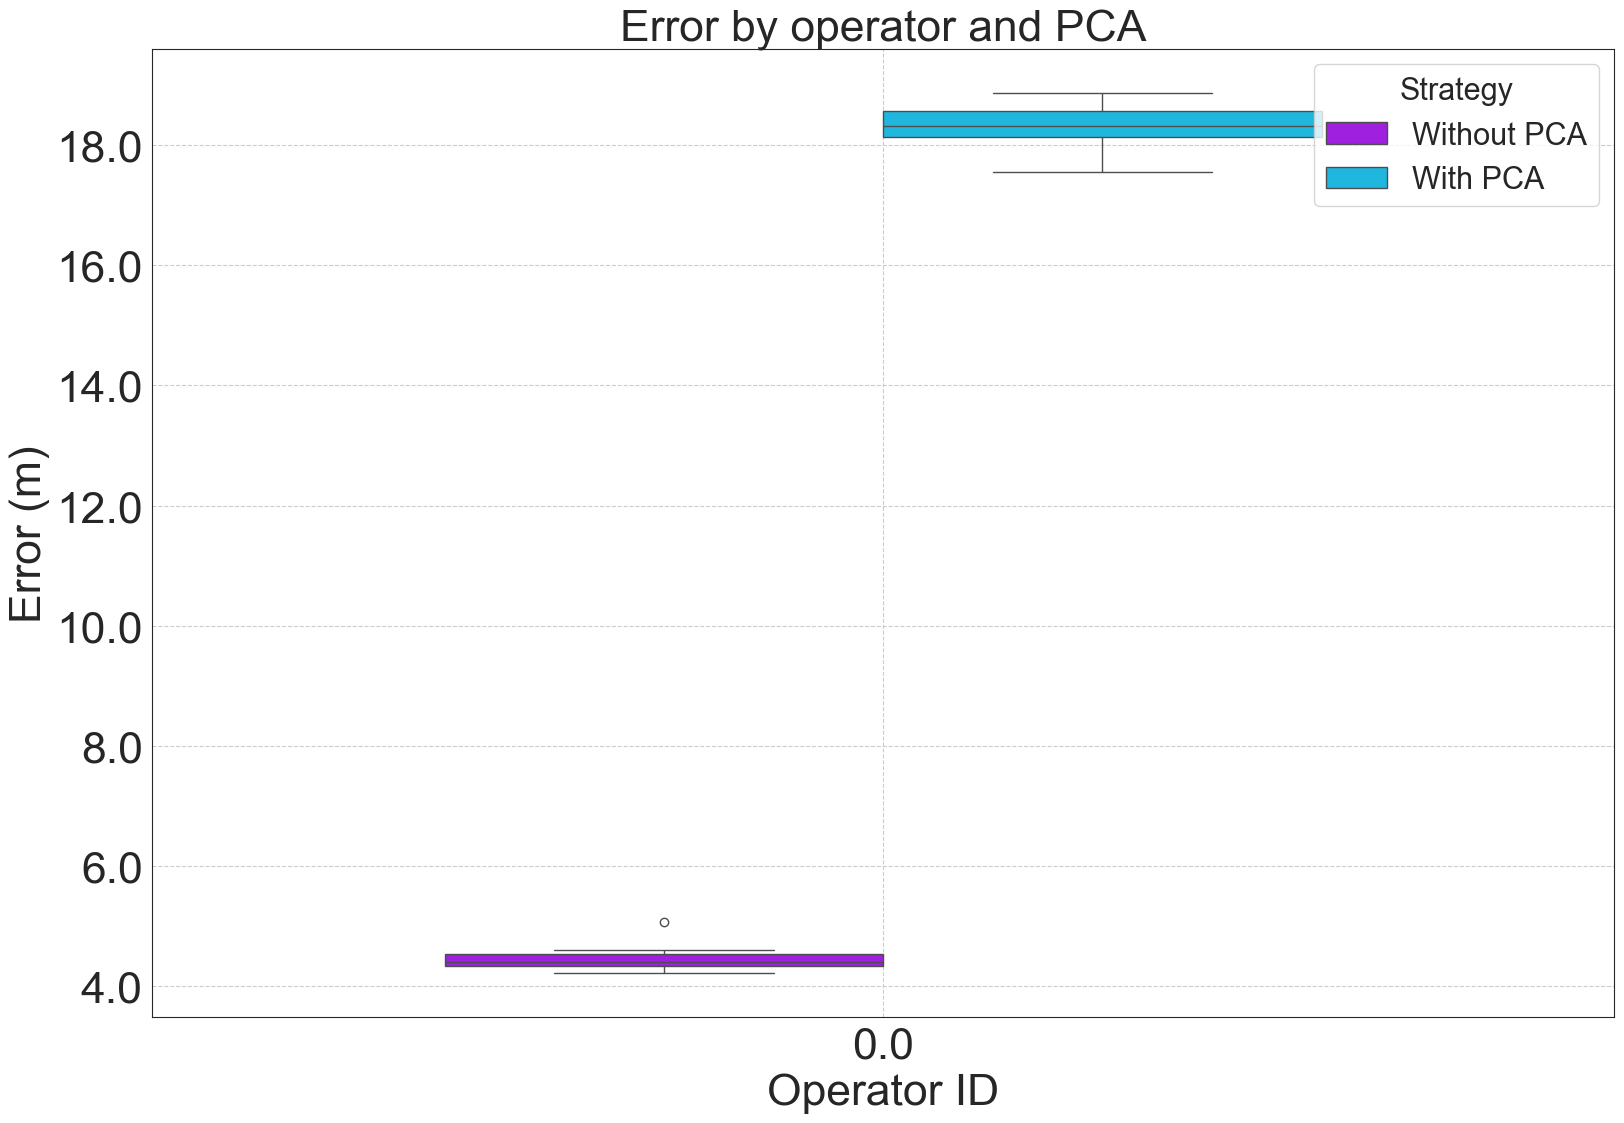

In [135]:
result_df = result_df[result_df['operator'] == 10]


def plot_pca_experiment(data_df: pd.DataFrame):
    color_map = get_config('color_map.json', 'operatorId')

    plt.rcParams.update({"font.size": 32})
    # Set the style to white background
    plt.figure(figsize=(17, 12))
    sns.set_style("white")

    sns.boxplot(x='n_clusters', y='error', hue='pca', palette=palette, data=data_df, width=0.6)

    # Add labels and title
    plt.xlabel('Operator ID')
    plt.ylabel('Error (m)')
    plt.title('Error by operator and PCA')

    # Improve the legend
    plt.legend(title='Strategy', fontsize='22', loc='upper right', title_fontsize=22)

    # Remove grid or make it very subtle
    plt.grid(linestyle='--')

    from matplotlib.ticker import FormatStrFormatter

    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    # Show the plot
    plt.tight_layout()
    plt.show()


plot_pca_experiment(result_df)